# Main experiment

## Thư viện và CUDA xử lý GPU

In [24]:
# Cell 1 — Kaggle runtime, thư viện, pytorch-tabnet và CUDA.
from pathlib import Path
import gc
import importlib.util
import os
import random
import shutil
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
KAGGLE_WORKING_ROOT = Path("/kaggle/working")
IS_KAGGLE = KAGGLE_INPUT_ROOT.is_dir() and KAGGLE_WORKING_ROOT.is_dir()
TABNET_PACKAGE = "pytorch-tabnet==4.1.0"
if IS_KAGGLE and importlib.util.find_spec("pytorch_tabnet") is None:
    print(f"Đang cài {TABNET_PACKAGE} trên Kaggle...")
    try:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", "--no-deps", TABNET_PACKAGE],
            check=True,
        )
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            "Không cài được pytorch-tabnet. Hãy bật Internet cho Kaggle Notebook rồi chạy lại Cell 1."
        ) from exc

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

try:
    import torch
except ImportError:
    torch = None
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None
try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    from pytorch_tabnet.metrics import Metric as TabNetMetric
except ImportError:
    TabNetClassifier = None
    TabNetMetric = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
if IS_KAGGLE:
    PROJECT_ROOT = KAGGLE_WORKING_ROOT / "FAIR_2026_Experiment"
else:
    local_cwd = Path.cwd().resolve()
    PROJECT_ROOT = next(
        (p for p in (local_cwd, local_cwd.parent) if (p / "Notebook").is_dir()),
        local_cwd,
    )
RESULTS_ROOT = PROJECT_ROOT / "results"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
legacy_results_root = RESULTS_ROOT / "one_fold"
if legacy_results_root.is_dir():
    shutil.rmtree(legacy_results_root)
    print(f"Đã xóa cấu trúc kết quả cũ không còn dùng: {legacy_results_root}")
OBSOLETE_RESULT_FILES = (
    "preprocessing_audit.csv", "validation_reference.csv",
    "feature_names.csv", "tabnet_training_history.csv",
)
for dataset_dir_name in ("MLG_ULB", "IEEE_CIS", "SPARKOV"):
    for fold_number in range(1, 6):
        fold_dir = RESULTS_ROOT / dataset_dir_name / f"fold_{fold_number:02d}"
        fold_dir.mkdir(parents=True, exist_ok=True)
        for obsolete_name in OBSOLETE_RESULT_FILES:
            (fold_dir / obsolete_name).unlink(missing_ok=True)

RANDOM_STATE = 42
SEED = RANDOM_STATE
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
CUDA_AVAILABLE = bool(torch is not None and torch.cuda.is_available())
GPU_COUNT = torch.cuda.device_count() if CUDA_AVAILABLE else 0
GPU_NAMES = [torch.cuda.get_device_name(i) for i in range(GPU_COUNT)] if CUDA_AVAILABLE else []
if torch is not None:
    torch.manual_seed(RANDOM_STATE)
    if CUDA_AVAILABLE:
        torch.cuda.manual_seed_all(RANDOM_STATE)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

DATA_HINTS = {
    "MLG_ULB": {"creditcard.csv": KAGGLE_INPUT_ROOT / "mlg-ulb-creditcardfraud" / "creditcard.csv"},
    "IEEE_CIS": {
        "train_transaction.csv": KAGGLE_INPUT_ROOT / "ieee-fraud-detection" / "train_transaction.csv",
        "train_identity.csv": KAGGLE_INPUT_ROOT / "ieee-fraud-detection" / "train_identity.csv",
    },
    "SPARKOV": {
        "fraudTrain.csv": KAGGLE_INPUT_ROOT / "fraud-detection" / "fraudTrain.csv",
        "fraudTest.csv": KAGGLE_INPUT_ROOT / "fraud-detection" / "fraudTest.csv",
    },
}

def resolve_input_file(filename, hinted_path):
    if hinted_path.is_file():
        return hinted_path
    matches = list(KAGGLE_INPUT_ROOT.rglob(filename)) if IS_KAGGLE else list(PROJECT_ROOT.rglob(filename))
    if len(matches) != 1:
        raise FileNotFoundError(f"Cần đúng 1 file {filename}; tìm thấy {len(matches)}: {matches}")
    return matches[0]

PACKAGE_STATUS = {
    "torch": torch is not None,
    "xgboost": XGBClassifier is not None, "lightgbm": LGBMClassifier is not None,
    "catboost": CatBoostClassifier is not None, "pytorch_tabnet": TabNetClassifier is not None,
}
print(f"Kaggle={IS_KAGGLE} | CUDA={CUDA_AVAILABLE} | GPUs={GPU_NAMES}")
print("Package status:", PACKAGE_STATUS)
print("Results root:", RESULTS_ROOT)

Kaggle=True | CUDA=True | GPUs=['Tesla T4', 'Tesla T4']
Package status: {'torch': True, 'xgboost': True, 'lightgbm': True, 'catboost': True, 'pytorch_tabnet': True}
Results root: /kaggle/working/FAIR_2026_Experiment/results


## Trích xuất xử lý dữ liệu

Giới hạn: Chỉ lưu 1 fold để thực hiện huấn luyện ngay và lấy kết quả chạy với 13 models, sau đó giải phóng fold để chạy tiếp các fold còn lại.

Chọn dataset để thực hiện chạy

In [25]:
# Cell 2 — chọn đúng một dataset cho mỗi lần chạy notebook.
DATASET_NAME = "MLG_ULB"  # MLG_ULB | IEEE_CIS | SPARKOV
if DATASET_NAME not in DATA_HINTS:
    raise ValueError(f"DATASET_NAME không hợp lệ: {DATASET_NAME}")
RESOLVED_INPUTS = {
    name: resolve_input_file(name, hint)
    for name, hint in DATA_HINTS[DATASET_NAME].items()
}
for name, path in RESOLVED_INPUTS.items():
    print(f"{name}: {path}")

creditcard.csv: /kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv


EDA dữ liệu được chọn để quan sát và đảm bảo

In [26]:
# Kiểm tra nhanh đúng input/schema trước khi đọc toàn bộ dữ liệu ở Cell 4.
required_columns_by_file = {
    "creditcard.csv": {"Time", "Amount", "Class", *{f"V{i}" for i in range(1, 29)}},
    "train_transaction.csv": {"TransactionID", "isFraud"},
    "train_identity.csv": {"TransactionID"},
    "fraudTrain.csv": {"trans_num", "trans_date_trans_time", "is_fraud"},
    "fraudTest.csv": {"trans_num", "trans_date_trans_time", "is_fraud"},
}
input_checks = []
for filename, path in RESOLVED_INPUTS.items():
    preview = pd.read_csv(path, nrows=5)
    missing = sorted(required_columns_by_file[filename] - set(preview.columns))
    input_checks.append({
        "file": filename, "size_gb": path.stat().st_size / 1024**3,
        "columns": len(preview.columns), "required_schema_ok": not missing,
        "missing_required": "|".join(missing),
    })
    if missing:
        raise ValueError(f"{filename} thiếu cột bắt buộc: {missing}")
display(pd.DataFrame(input_checks))
display(pd.read_csv(next(iter(RESOLVED_INPUTS.values())), nrows=5))

,file,size_gb,columns,required_schema_ok,missing_required
0,creditcard.csv,0.14047,31,True,


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Chọn fold thực hiện (từ 1 đến 5 ứng với mỗi loại dữ liệu thực hiện ULB, IEEE Fraud, Sparkov)

In [27]:
# Cell 3 — chọn một fold đầy đủ để chạy reproduction.
SELECTED_FOLD = 2
N_SPLITS = 5
REMOVE_MLG_DUPLICATES = False

if SELECTED_FOLD not in range(1, N_SPLITS + 1):
    raise ValueError(f"SELECTED_FOLD phải từ 1 đến {N_SPLITS}")
print({
    "dataset": DATASET_NAME, "fold": SELECTED_FOLD,
    "full_fold": True, "remove_mlg_duplicates": REMOVE_MLG_DUPLICATES,
})

{'dataset': 'MLG_ULB', 'fold': 2, 'full_fold': True, 'remove_mlg_duplicates': False}


## Kiểm tra kết quả trích xuất và quan sát fold

In [28]:
# Cell 4 — load, split, preprocessing train-only, SMOTE và validation gate.
def make_dense_ohe():
    return OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)

# 1) Load và xử lý deterministic theo từng dataset.
id_series = None
preprocessing_notes = []
if DATASET_NAME == "MLG_ULB":
    raw_df = pd.read_csv(RESOLVED_INPUTS["creditcard.csv"])
    expected = ["Time", *[f"V{i}" for i in range(1, 29)], "Amount", "Class"]
    missing_required = [c for c in expected if c not in raw_df.columns]
    assert not missing_required, f"Thiếu cột MLG: {missing_required}"
    duplicate_count = int(raw_df.duplicated().sum())
    if REMOVE_MLG_DUPLICATES:
        raw_df = raw_df.drop_duplicates().reset_index(drop=True)
    X_raw = raw_df.drop(columns=["Class"]).copy()
    y_raw = raw_df["Class"].astype(np.int8).copy()
    target_name = "Class"
    preprocessing_notes.append(f"duplicates={duplicate_count}, removed={REMOVE_MLG_DUPLICATES}")
elif DATASET_NAME == "IEEE_CIS":
    tx = pd.read_csv(RESOLVED_INPUTS["train_transaction.csv"])
    identity = pd.read_csv(RESOLVED_INPUTS["train_identity.csv"])
    raw_df = tx.merge(identity, on="TransactionID", how="left")
    assert len(raw_df) == len(tx), "LEFT JOIN IEEE làm thay đổi số transaction"
    id_series = raw_df["TransactionID"].copy()
    y_raw = raw_df["isFraud"].astype(np.int8).copy()
    X_raw = raw_df.drop(columns=["isFraud", "TransactionID"]).copy()
    target_name = "isFraud"
    preprocessing_notes.append("IEEE transaction LEFT JOIN identity; TransactionID excluded")
    del tx, identity
else:
    raw_df = pd.read_csv(RESOLVED_INPUTS["fraudTrain.csv"])
    if "Unnamed: 0" in raw_df.columns:
        raw_df = raw_df.drop(columns=["Unnamed: 0"])
    id_series = raw_df["trans_num"].copy() if "trans_num" in raw_df.columns else None
    raw_df = raw_df.drop(columns=[c for c in ["trans_num", "cc_num", "first", "last", "street"] if c in raw_df.columns])
    tx_dt = pd.to_datetime(raw_df["trans_date_trans_time"], errors="coerce")
    raw_df["transaction_hour"] = tx_dt.dt.hour
    raw_df["transaction_day"] = tx_dt.dt.day
    raw_df["transaction_month"] = tx_dt.dt.month
    raw_df["transaction_weekday"] = tx_dt.dt.dayofweek
    raw_df["is_weekend"] = (tx_dt.dt.dayofweek >= 5).astype(np.int8)
    raw_df = raw_df.drop(columns=["trans_date_trans_time"])
    y_raw = raw_df["is_fraud"].astype(np.int8).copy()
    X_raw = raw_df.drop(columns=["is_fraud"]).copy()
    target_name = "is_fraud"
    preprocessing_notes.append("Sparkov time features enabled; technical/person IDs excluded")

# 2) Tạo fold trên toàn bộ dữ liệu trước mọi fit preprocessing.
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
all_fold_indices = list(skf.split(X_raw, y_raw))
full_train_idx, full_valid_idx = all_fold_indices[SELECTED_FOLD - 1]
assert len(np.intersect1d(full_train_idx, full_valid_idx)) == 0

# IEEE: danh sách drop missing được học từ full training fold, không từ validation.
drop_cols = []
if DATASET_NAME == "IEEE_CIS":
    train_missing_ratio = X_raw.iloc[full_train_idx].isna().mean()
    drop_cols = train_missing_ratio[train_missing_ratio > 0.50].index.tolist()
    X_raw = X_raw.drop(columns=drop_cols)
    preprocessing_notes.append(f"drop_missing_gt_50pct_from_train={len(drop_cols)}")

# 3) Dùng nguyên vẹn toàn bộ train/validation của fold được chọn.
train_source_idx = np.asarray(full_train_idx)
valid_source_idx = np.asarray(full_valid_idx)
X_train_raw = X_raw.iloc[train_source_idx].copy()
y_train_raw = y_raw.iloc[train_source_idx].copy()
X_valid_raw = X_raw.iloc[valid_source_idx].copy()
y_valid = y_raw.iloc[valid_source_idx].to_numpy(dtype=np.int8)

# 4) Fit preprocessing trên train và transform validation.
if DATASET_NAME == "MLG_ULB":
    preprocessor = StandardScaler()
    X_train_proc = preprocessor.fit_transform(X_train_raw.astype(np.float32)).astype(np.float32, copy=False)
    X_valid = preprocessor.transform(X_valid_raw.astype(np.float32)).astype(np.float32, copy=False)
    feature_names = X_train_raw.columns.astype(str).tolist()
else:
    categorical_cols = X_train_raw.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    numeric_cols = [c for c in X_train_raw.columns if c not in categorical_cols]
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=-999)),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_dense_ohe()),
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])
    X_train_raw[numeric_cols] = X_train_raw[numeric_cols].astype(np.float32)
    X_valid_raw[numeric_cols] = X_valid_raw[numeric_cols].astype(np.float32)
    X_train_proc = preprocessor.fit_transform(X_train_raw).astype(np.float32, copy=False)
    X_valid = preprocessor.transform(X_valid_raw).astype(np.float32, copy=False)
    feature_names = preprocessor.get_feature_names_out().astype(str).tolist()

minority_count = int(y_train_raw.value_counts().min())
assert minority_count > 5, f"Không đủ fraud cho SMOTE k=5: {minority_count}"
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=RANDOM_STATE)
X_train, y_train = smote.fit_resample(X_train_proc, y_train_raw)
X_train = np.asarray(X_train, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.int8)

# 5) Validation gate bắt buộc trước model.
checks = {
    "source_indices_disjoint": len(np.intersect1d(train_source_idx, valid_source_idx)) == 0,
    "feature_count_matches": X_train.shape[1] == X_valid.shape[1] == len(feature_names),
    "train_no_nan": not np.isnan(X_train).any(),
    "valid_no_nan": not np.isnan(X_valid).any(),
    "train_no_inf": np.isfinite(X_train).all(),
    "valid_no_inf": np.isfinite(X_valid).all(),
    "smote_train_balanced": len(np.unique(np.bincount(y_train))) == 1,
    "validation_not_smoted": len(y_valid) == len(valid_source_idx),
    "both_classes_present": set(np.unique(y_valid)) == {0, 1},
}
PREPROCESSING_VALIDATED = all(checks.values())
if not PREPROCESSING_VALIDATED:
    raise RuntimeError(f"Preprocessing validation failed: {checks}")
valid_reference = pd.DataFrame({"source_index": valid_source_idx, target_name: y_valid})
if id_series is not None:
    valid_reference["record_id"] = id_series.iloc[valid_source_idx].to_numpy()
DATA_VARIANT = ("without_duplicates" if REMOVE_MLG_DUPLICATES else "with_duplicates") if DATASET_NAME == "MLG_ULB" else "reproduction"
audit = pd.DataFrame([{
    "dataset": DATASET_NAME, "variant": DATA_VARIANT, "fold": SELECTED_FOLD,
    "raw_rows": len(y_raw), "train_before_smote": len(y_train_raw),
    "train_after_smote": len(y_train), "validation_rows": len(y_valid),
    "features": X_train.shape[1], "validation_fraud_rate": float(y_valid.mean()),
    "train_matrix_gb": X_train.nbytes / 1024**3,
    "notes": "; ".join(preprocessing_notes),
}])
RESULT_DATASET_ROOT = RESULTS_ROOT / DATASET_NAME
run_dir = RESULT_DATASET_ROOT / f"fold_{SELECTED_FOLD:02d}"
run_dir.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame({"check": checks.keys(), "passed": checks.values()}))
display(audit)
print("Train class:", np.bincount(y_train), "Validation class:", np.bincount(y_valid))
print("PREPROCESSING_VALIDATED =", PREPROCESSING_VALIDATED)
del raw_df, X_raw, y_raw, X_train_raw, X_valid_raw, X_train_proc
gc.collect()

,check,passed
0,source_indices_disjoint,True
1,feature_count_matches,True
2,train_no_nan,True
3,valid_no_nan,True
4,train_no_inf,True
5,valid_no_inf,True
6,smote_train_balanced,True
7,validation_not_smoted,True
8,both_classes_present,True


,dataset,variant,fold,raw_rows,train_before_smote,train_after_smote,validation_rows,features,validation_fraud_rate,train_matrix_gb,notes
0,MLG_ULB,with_duplicates,2,284807,227845,454904,56962,30,0.001738,0.050839,"duplicates=1081, removed=False"


Train class: [227452 227452] Validation class: [56863    99]
PREPROCESSING_VALIDATED = True


0

## Trích xuất mô hình (13 mô hình chính)

In [29]:
# Cell 5 — cổng kiểm định và hàm đánh giá dùng chung cho cả 13 mô hình.
if not globals().get("PREPROCESSING_VALIDATED", False):
    raise RuntimeError("Dữ liệu chưa vượt qua kiểm định ở Cell 4; không được huấn luyện.")

experiment_rows = []

def record_unavailable(model_name, reason):
    row = {
        "dataset": DATASET_NAME, "variant": DATA_VARIANT, "fold": SELECTED_FOLD,
        "model": model_name, "status": "unavailable", "device": "-",
        "precision": np.nan, "recall": np.nan, "f1": np.nan,
        "roc_auc": np.nan, "pr_auc": np.nan,
        "tn": np.nan, "fp": np.nan, "fn": np.nan, "tp": np.nan,
        "fit_seconds": np.nan, "train_rows": len(y_train),
        "valid_rows": len(y_valid), "n_features": X_train.shape[1],
        "model_params": "", "note": str(reason)[:500],
    }
    experiment_rows.append(row)
    print(f"{model_name}: unavailable — {reason}")

def evaluate_fitted_model(model_name, model, fit_seconds, device, note=""):
    y_pred = np.asarray(model.predict(X_valid)).reshape(-1).astype(np.int8)
    if hasattr(model, "predict_proba"):
        y_score = np.asarray(model.predict_proba(X_valid))[:, 1]
    elif hasattr(model, "decision_function"):
        raw_score = np.asarray(model.decision_function(X_valid)).reshape(-1)
        y_score = 1.0 / (1.0 + np.exp(-np.clip(raw_score, -30, 30)))
    else:
        y_score = y_pred.astype(np.float32)
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred, labels=[0, 1]).ravel()
    row = {
        "dataset": DATASET_NAME, "variant": DATA_VARIANT, "fold": SELECTED_FOLD,
        "model": model_name, "status": "ok", "device": device,
        "precision": precision_score(y_valid, y_pred, zero_division=0),
        "recall": recall_score(y_valid, y_pred, zero_division=0),
        "f1": f1_score(y_valid, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_score),
        "pr_auc": average_precision_score(y_valid, y_score),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "fit_seconds": float(fit_seconds), "train_rows": len(y_train),
        "valid_rows": len(y_valid), "n_features": X_train.shape[1],
        "model_params": repr(model.get_params(deep=False)) if hasattr(model, "get_params") else "",
        "note": note,
    }
    experiment_rows.append(row)
    print(f"{model_name}: F1={row['f1']:.6f}, PR-AUC={row['pr_auc']:.6f}, {fit_seconds:.1f}s, {device}")

def fit_and_evaluate(model_name, estimator, device="CPU", fallback=None):
    start = time.perf_counter()
    used_device, note = device, ""
    try:
        estimator.fit(X_train, y_train)
    except Exception as exc:
        if fallback is None:
            record_unavailable(model_name, exc)
            return
        note = f"GPU fallback: {type(exc).__name__}: {exc}"[:500]
        print(f"{model_name}: GPU không khả dụng, chuyển sang CPU.")
        del estimator
        gc.collect()
        if torch is not None and torch.cuda.is_available():
            torch.cuda.empty_cache()
        estimator, used_device = fallback(), "CPU fallback"
        start = time.perf_counter()
        try:
            estimator.fit(X_train, y_train)
        except Exception as fallback_exc:
            record_unavailable(model_name, fallback_exc)
            return
    evaluate_fitted_model(model_name, estimator, time.perf_counter() - start, used_device, note)
    del estimator
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Cổng kiểm định đã mở. Bắt đầu huấn luyện tuần tự để giới hạn RAM/VRAM.")

Cổng kiểm định đã mở. Bắt đầu huấn luyện tuần tự để giới hạn RAM/VRAM.


### Khởi tạo toàn bộ mô hình nghiên cứu

### Huấn luyện và đánh giá mô hình

#### 1. Mô hình Logistic Regression

In [30]:
fit_and_evaluate(
    "Logistic Regression",
    LogisticRegression(max_iter=300, solver="liblinear", random_state=SEED),
)

Logistic Regression: F1=0.113185, PR-AUC=0.727137, 5.9s, CPU


#### 2. Mô hình Decision Tree

In [31]:
fit_and_evaluate(
    "Decision Tree",
    DecisionTreeClassifier(random_state=SEED),
)

Decision Tree: F1=0.548495, PR-AUC=0.339894, 52.1s, CPU


#### 3. Mô hình Random Forest

In [32]:
fit_and_evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
)

Random Forest: F1=0.906250, PR-AUC=0.899751, 174.5s, CPU


#### 4. Mô hình LightGBM

In [33]:
if LGBMClassifier is None:
    record_unavailable("LightGBM", "lightgbm chưa có trong Kaggle image")
else:
    lgbm_common = dict(n_estimators=200, learning_rate=0.1, objective="binary", random_state=SEED, verbosity=-1)
    lgbm_gpu = LGBMClassifier(**lgbm_common, device_type="gpu") if CUDA_AVAILABLE else LGBMClassifier(**lgbm_common)
    lgbm_fallback = (lambda: LGBMClassifier(**lgbm_common)) if CUDA_AVAILABLE else None
    fit_and_evaluate("LightGBM", lgbm_gpu, "GPU" if CUDA_AVAILABLE else "CPU", lgbm_fallback)

LightGBM: F1=0.653846, PR-AUC=0.450797, 6.3s, GPU


#### 5. Mô hình CatBoost

In [34]:
if CatBoostClassifier is None:
    record_unavailable("CatBoost", "catboost chưa có trong Kaggle image")
else:
    cat_common = dict(iterations=200, learning_rate=0.1, loss_function="Logloss", verbose=False, random_seed=SEED)
    cat_devices = ":".join(str(i) for i in range(GPU_COUNT))
    cat_gpu = CatBoostClassifier(**cat_common, task_type="GPU", devices=cat_devices) if CUDA_AVAILABLE else CatBoostClassifier(**cat_common)
    cat_fallback = (lambda: CatBoostClassifier(**cat_common)) if CUDA_AVAILABLE else None
    fit_and_evaluate("CatBoost", cat_gpu, "GPU" if CUDA_AVAILABLE else "CPU", cat_fallback)

CatBoost: F1=0.661710, PR-AUC=0.884568, 2.9s, GPU


#### 6. Mô hình XGBoost

In [35]:
if XGBClassifier is None:
    record_unavailable("XGBoost", "xgboost chưa có trong Kaggle image")
else:
    xgb_common = dict(n_estimators=200, learning_rate=0.1, objective="binary:logistic", max_depth=6, tree_method="hist", eval_metric="logloss", random_state=SEED, n_jobs=-1)
    xgb_gpu = XGBClassifier(**xgb_common, device="cuda") if CUDA_AVAILABLE else XGBClassifier(**xgb_common)
    xgb_fallback = (lambda: XGBClassifier(**xgb_common, device="cpu")) if CUDA_AVAILABLE else None
    fit_and_evaluate("XGBoost", xgb_gpu, "GPU" if CUDA_AVAILABLE else "CPU", xgb_fallback)

XGBoost: F1=0.775330, PR-AUC=0.890413, 2.6s, GPU


#### 7. Mô hình AdaBoost

In [36]:
fit_and_evaluate(
    "AdaBoost",
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED),
)

AdaBoost: F1=0.174163, PR-AUC=0.761889, 376.2s, CPU


#### 8. Mô hình TabNet

epoch 0  | loss: 0.0599  | train_smote_auc: 0.99968 | train_smote_f1: 0.99533 | valid_real_auc: 0.95682 | valid_real_f1: 0.33397 |  0:00:29s
epoch 10 | loss: 0.00378 | train_smote_auc: 0.99997 | train_smote_f1: 0.99932 | valid_real_auc: 0.96362 | valid_real_f1: 0.57627 |  0:05:32s
epoch 20 | loss: 0.00214 | train_smote_auc: 0.99999 | train_smote_f1: 0.99974 | valid_real_auc: 0.96635 | valid_real_f1: 0.75221 |  0:10:21s
epoch 30 | loss: 0.00202 | train_smote_auc: 0.99998 | train_smote_f1: 0.99981 | valid_real_auc: 0.96975 | valid_real_f1: 0.78873 |  0:15:03s
epoch 40 | loss: 0.00097 | train_smote_auc: 1.0     | train_smote_f1: 0.99991 | valid_real_auc: 0.97441 | valid_real_f1: 0.80808 |  0:19:44s
epoch 50 | loss: 0.00127 | train_smote_auc: 1.0     | train_smote_f1: 0.99989 | valid_real_auc: 0.96138 | valid_real_f1: 0.79808 |  0:24:22s
epoch 60 | loss: 0.00089 | train_smote_auc: 0.99999 | train_smote_f1: 0.99991 | valid_real_auc: 0.94518 | valid_real_f1: 0.79621 |  0:28:55s
epoch 70 | lo

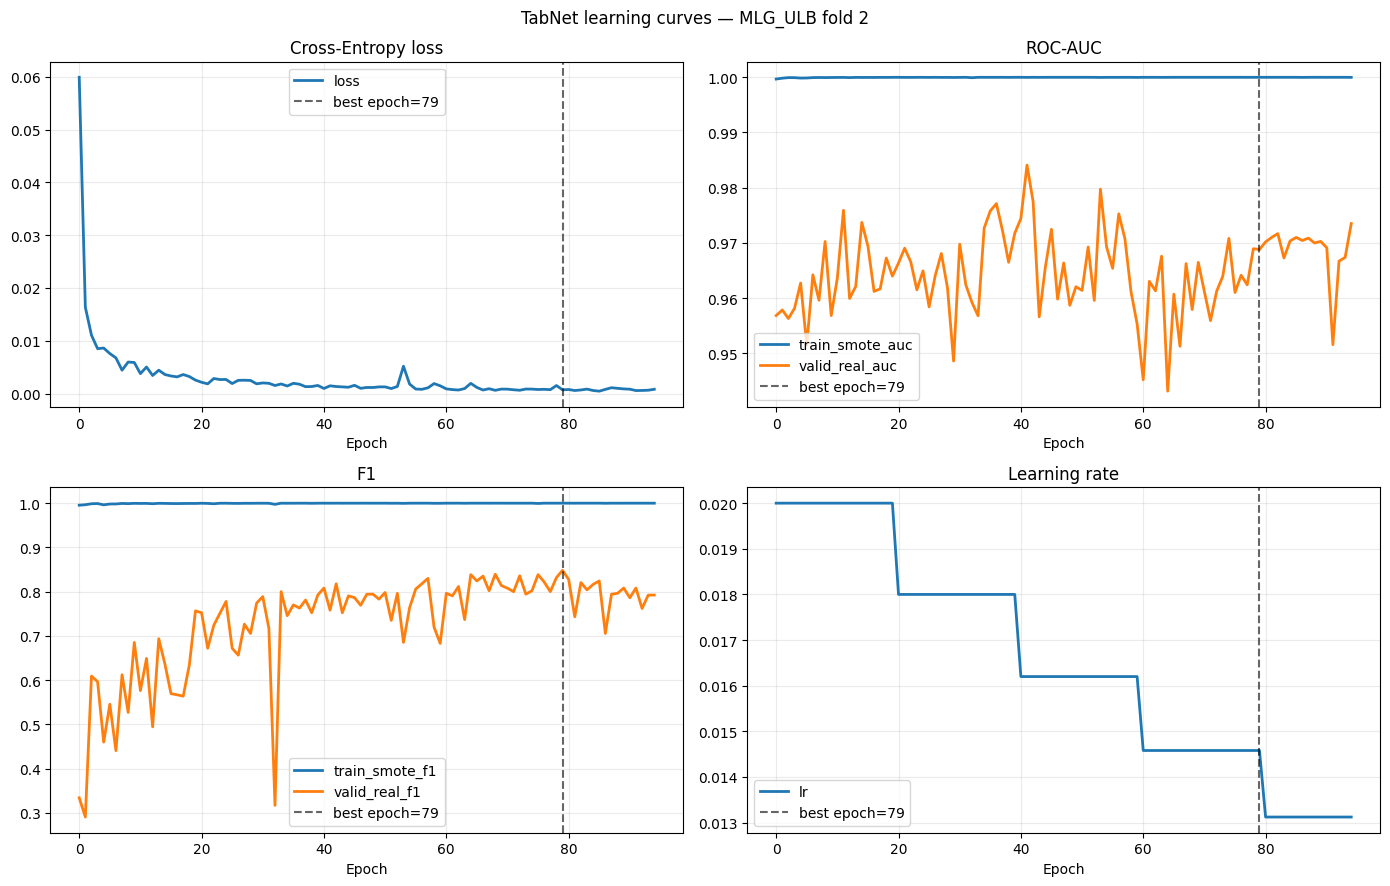

Đã lưu learning curves: /kaggle/working/FAIR_2026_Experiment/results/MLG_ULB/fold_02/tabnet_learning_curves.png


In [37]:
if torch is None:
    record_unavailable("TabNet", "PyTorch không có trong Kaggle image hoặc accelerator chưa được khởi tạo")
elif TabNetClassifier is None or TabNetMetric is None:
    record_unavailable("TabNet", "pytorch-tabnet chưa được import; hãy chạy lại Cell 1")
else:
    class TabNetF1Metric(TabNetMetric):
        """F1 tại ngưỡng argmax; metric cuối nên được dùng cho early stopping."""
        def __init__(self):
            self._name = "f1"
            self._maximize = True

        def __call__(self, y_true, y_score):
            y_pred = np.argmax(y_score, axis=1)
            return f1_score(y_true, y_pred, zero_division=0)

    tabnet = TabNetClassifier(
        n_d=64, n_a=64, lambda_sparse=1e-3, seed=SEED,
        optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=0.02),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params=dict(step_size=20, gamma=0.9, is_batch_level=False),
        device_name="cuda" if CUDA_AVAILABLE else "cpu", verbose=10,
    )
    start = time.perf_counter()
    try:
        tabnet.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_valid, y_valid)],
            eval_name=["train_smote", "valid_real"],
            eval_metric=["auc", TabNetF1Metric],
            loss_fn=torch.nn.functional.cross_entropy,
            max_epochs=100, patience=15, batch_size=1024,
            virtual_batch_size=128, num_workers=0, drop_last=False,
        )
    except Exception as exc:
        record_unavailable("TabNet", exc)
    else:
        evaluate_fitted_model(
            "TabNet", tabnet, time.perf_counter() - start,
            "GPU" if CUDA_AVAILABLE else "CPU",
            note="CrossEntropy; lambda_sparse=1e-3; early_stopping=valid_real_f1",
        )

        # Lịch sử đầy đủ để kiểm tra overfit và tái lập biểu đồ theo từng fold.
        try:
            tabnet_history = dict(tabnet.history.history)
            history_df = pd.DataFrame({
                key: pd.Series(np.asarray(values))
                for key, values in tabnet_history.items()
            })
            history_df.index.name = "epoch"
            curve_groups = [
                ("Cross-Entropy loss", ["loss"]),
                ("ROC-AUC", ["train_smote_auc", "valid_real_auc"]),
                ("F1", ["train_smote_f1", "valid_real_f1"]),
                ("Learning rate", ["lr"]),
            ]
            fig, axes = plt.subplots(2, 2, figsize=(14, 9))
            best_epoch = getattr(tabnet, "best_epoch", None)
            for ax, (title, columns) in zip(axes.ravel(), curve_groups):
                plotted = False
                for column in columns:
                    if column in history_df and history_df[column].notna().any():
                        ax.plot(history_df.index, history_df[column], label=column, linewidth=2)
                        plotted = True
                if best_epoch is not None:
                    ax.axvline(best_epoch, color="black", linestyle="--", alpha=0.6, label=f"best epoch={best_epoch}")
                ax.set(title=title, xlabel="Epoch")
                ax.grid(alpha=0.25)
                if plotted:
                    ax.legend()
            fig.suptitle(f"TabNet learning curves — {DATASET_NAME} fold {SELECTED_FOLD}")
            plt.tight_layout()
            curve_path = run_dir / "tabnet_learning_curves.png"
            fig.savefig(curve_path, dpi=160, bbox_inches="tight")
            plt.show()
            print(f"Đã lưu learning curves: {curve_path}")
        except Exception as curve_exc:
            print(f"TabNet đã đánh giá thành công nhưng không vẽ được learning curves: {curve_exc}")

    del tabnet
    gc.collect()
    if CUDA_AVAILABLE:
        torch.cuda.empty_cache()


#### 9. Mô hình Extra Trees

In [38]:
fit_and_evaluate(
    "Extra Trees",
    ExtraTreesClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
)

Extra Trees: F1=0.897297, PR-AUC=0.909480, 19.2s, CPU


#### 10. Mô hình KNN

In [39]:
fit_and_evaluate(
    "KNN",
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
)

KNN: F1=0.616487, PR-AUC=0.639001, 0.0s, CPU


#### 11. Mô hình LDA

In [40]:
fit_and_evaluate(
    "LDA",
    LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
)

LDA: F1=0.165703, PR-AUC=0.294891, 0.7s, CPU


#### 12. Mô hình Naive Bayes

In [41]:
fit_and_evaluate(
    "Naive Bayes",
    GaussianNB(),
)

Naive Bayes: F1=0.110899, PR-AUC=0.093228, 0.1s, CPU


#### 13. Mô hình Gradient Boosting

In [42]:
fit_and_evaluate(
    "Gradient Boosting",
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED),
)

Gradient Boosting: F1=0.180215, PR-AUC=0.761820, 986.0s, CPU


### Ma trận và các chỉ số đánh giá theo nghiên cứu

,model,status,device,precision,recall,f1,roc_auc,pr_auc,fit_seconds
2,Random Forest,ok,CPU,0.935484,0.878788,0.906250,0.970430,0.899751,174.461452
8,Extra Trees,ok,CPU,0.965116,0.838384,0.897297,0.979425,0.909480,19.174874
7,TabNet,ok,GPU,0.880435,0.818182,0.848168,0.968801,0.860919,2713.759089
5,XGBoost,ok,GPU,0.687500,0.888889,0.775330,0.971037,0.890413,2.629278
4,CatBoost,ok,GPU,0.523529,0.898990,0.661710,0.965151,0.884568,2.872878
3,LightGBM,ok,GPU,0.527950,0.858586,0.653846,0.955473,0.450797,6.275823
9,KNN,ok,CPU,0.477778,0.868687,0.616487,0.938963,0.639001,0.023125
1,Decision Tree,ok,CPU,0.410000,0.828283,0.548495,0.913104,0.339894,52.125065
12,Gradient Boosting,ok,CPU,0.099783,0.929293,0.180215,0.969419,0.761820,985.971098
6,AdaBoost,ok,CPU,0.096195,0.919192,0.174163,0.973614,0.761889,376.237465


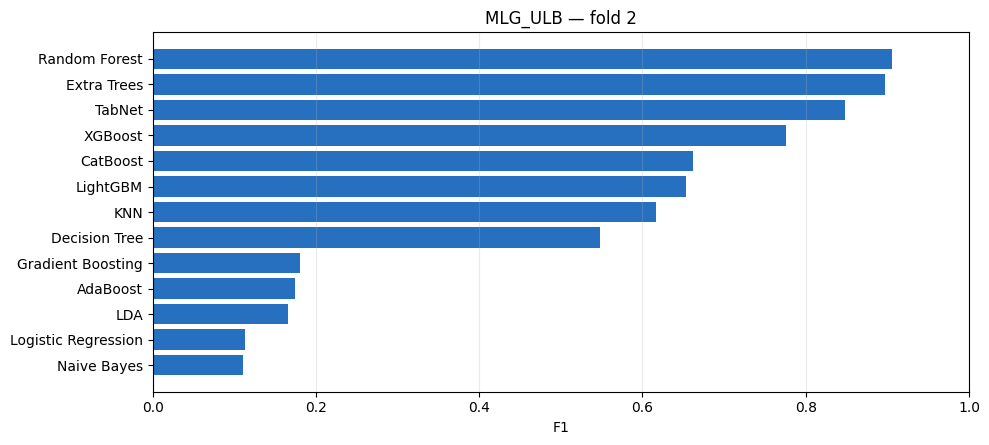

In [43]:
# Cell 19 — bảng metrics và confusion matrix của toàn bộ mô hình đã chạy.
results_df = pd.DataFrame(experiment_rows)
expected_models = [
    "Logistic Regression", "Decision Tree", "Random Forest", "LightGBM",
    "CatBoost", "XGBoost", "AdaBoost", "TabNet", "Extra Trees",
    "KNN", "LDA", "Naive Bayes", "Gradient Boosting",
]
assert results_df["model"].tolist() == expected_models, "Phải chạy tuần tự đủ 13 cell mô hình"
metric_cols = ["precision", "recall", "f1", "roc_auc", "pr_auc"]
display(results_df[["model", "status", "device", *metric_cols, "fit_seconds"]].sort_values("f1", ascending=False))

ok_df = results_df.query("status == 'ok'").copy()
if not ok_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(ok_df))))
    plot_df = ok_df.sort_values("f1")
    ax.barh(plot_df["model"], plot_df["f1"], color="#276FBF")
    ax.set(xlabel="F1", title=f"{DATASET_NAME} — fold {SELECTED_FOLD}", xlim=(0, 1))
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

### Lưu kết quả fold tương ứng với dataset tương ứng

Lưu vào dataset tương ứng với fold tương ứng. Sau đó sang cell tiếp theo sẽ khởi chạy kết quả đánh giá hiệu suất các mô hình trên tập dataset tương ứng một khi đủ toàn bộ các fold (chỉ chạy khi đủ toàn bộ fold)

In [44]:
# Cell 20 — chỉ lưu metrics cần thiết của 13 mô hình cho fold hiện tại.
metric_columns = [
    "dataset", "fold", "model",
    "precision", "recall", "f1", "roc_auc", "pr_auc",
    "tn", "fp", "fn", "tp",
]
metrics_path = run_dir / "model_metrics.csv"
results_df.loc[:, metric_columns].to_csv(metrics_path, index=False)
print(f"Đã lưu metrics: {metrics_path}")
print(f"Kích thước file: {metrics_path.stat().st_size / 1024**2:.3f} MiB")


Đã lưu metrics: /kaggle/working/FAIR_2026_Experiment/results/MLG_ULB/fold_02/model_metrics.csv
Kích thước file: 0.002 MiB


Lưu kết quả của dataset với 13 mô hình các mectrics với trung bình và cả độ lệch chuẩn.

In [45]:
# Cell 21 — tổng hợp mean/std khi dataset hiện tại đã có đủ 5 fold.
fold_metric_paths = sorted(RESULT_DATASET_ROOT.glob("fold_*/model_metrics.csv"))
available_folds = sorted({int(path.parent.name.split('_')[-1]) for path in fold_metric_paths})
print("Fold đã có:", available_folds)
if available_folds != list(range(1, N_SPLITS + 1)):
    print(f"Chưa tổng hợp: cần đủ fold 1..{N_SPLITS} cho {DATASET_NAME}.")
else:
    all_folds_df = pd.concat([pd.read_csv(path) for path in fold_metric_paths], ignore_index=True)
    successful = all_folds_df.dropna(subset=["f1"])
    summary_df = successful.groupby("model")[["precision", "recall", "f1", "roc_auc", "pr_auc"]].agg(["mean", "std"])
    summary_df.columns = [f"{metric}_{stat}" for metric, stat in summary_df.columns]
    summary_df = summary_df.reset_index().sort_values("f1_mean", ascending=False)
    summary_path = RESULT_DATASET_ROOT / "summary_5fold.csv"
    summary_df.to_csv(summary_path, index=False)
    display(summary_df)
    print(f"Đã lưu tổng hợp 5-fold: {summary_path}")

# Giải phóng ma trận lớn sau khi đã lưu metrics.
del X_train, X_valid, y_train, y_valid
gc.collect()
if torch is not None and torch.cuda.is_available():
    torch.cuda.empty_cache()

Fold đã có: [1, 2]
Chưa tổng hợp: cần đủ fold 1..5 cho MLG_ULB.
